Decodability of HSA 
- decodability of HSA before and after first shelter exposure
- decodability of HSA across sessions over time
- timecourse of HSA decodability after first shelter introduction
- relationship to first shelter visit/ homings?

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_17aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_17aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_2ndSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_shelt_4mar      

from behave_analysis.database.Experiments.JAL007_ex import JAL7_empty_shelter_5mar

from behave_analysis.database.Experiments.JAL008_ex import JAL8_shelt_22apr

experiments_objects = [JAL005_2ndSept,JAL4_17aug, JAL3_17aug, JAL8_shelt_22apr, JAL7_empty_shelter_5mar, JAL6_shelt_4mar]#, JAL005_5thSept]

In [2]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features, extract_pa_across_sesh

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
import re
%matplotlib inline

In [3]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\LDA_overview"
conditions = ['pre_shelter',"shelter_present"]
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']

In [40]:
""" Across sessions:
Pull out the pred.acc. for a certain set of settings"""

# fixed vars
settings = 'all_angles_subsampled_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings, bar_angles = False)

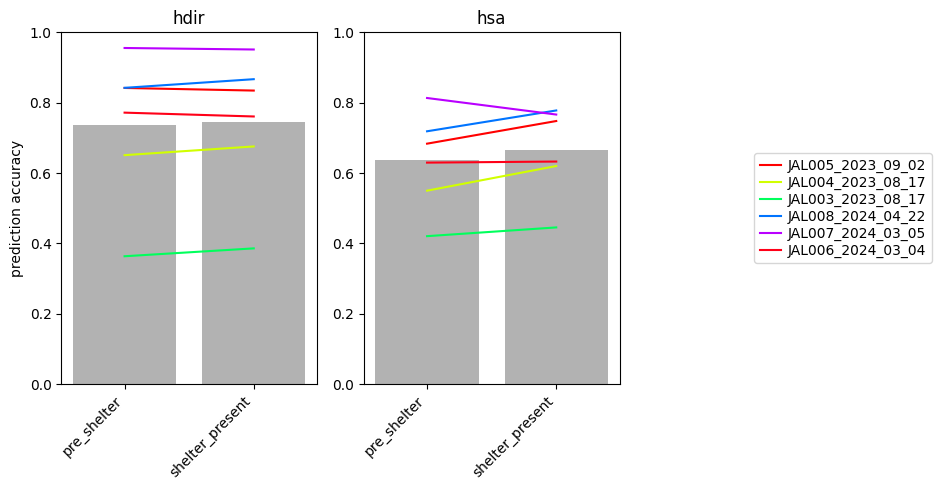

In [41]:
'''Plot the predicton accuracy for all sessions for the standard angles'''
all_angles = ['hdir','hsa']
fig, axs = plt.subplots(1,len(all_angles))
plt.rcParams['figure.figsize'] = [7, 7]
for idx, a in enumerate(all_angles):
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(pa[a])))))
    axs[idx].plot(conditions,pa[a].T)
    axs[idx].bar(conditions,np.mean(pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([0,1])
axs[idx].legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.5, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
axs[0].set_ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('hsa_pa_allsesh_'+settings+'.png'))

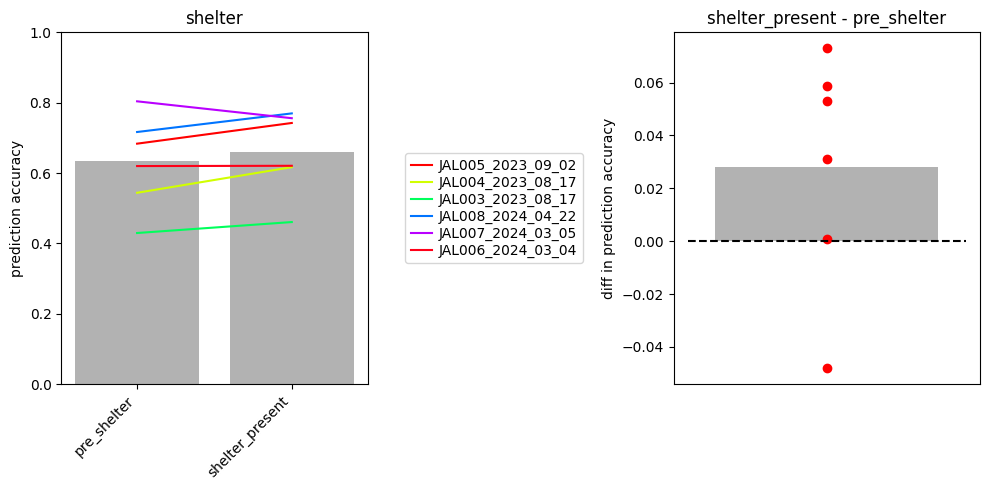

In [43]:
'''Plot the predicton accuracy for all sessions for the standard angles'''
fig, axs = plt.subplots(1,2)
plt.rcParams['figure.figsize'] = [10, 5]
a = 'shelter'
axs[0].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(avg_pa[a])))))
axs[0].plot(conditions,avg_pa[a].T)
axs[0].bar(conditions,np.mean(avg_pa[a],axis=0),color = 'k',alpha = .3)
axs[0].set_title(a)
axs[0].set_xticks(np.arange(len(conditions)))
axs[0].set_xticklabels(conditions,rotation = 45, ha="right")
axs[0].set_ylabel('prediction accuracy')
axs[0].set_ylim([0,1])

diff = avg_pa[a][:,1] - avg_pa[a][:,0]
axs[1].bar(1,np.mean(diff,axis = 0),color = 'k',alpha = .3)
axs[1].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(avg_pa[a])))))
axs[1].scatter(np.ones(len(diff)),diff)
axs[1].plot([.5,1.5],[0,0],'--k')
axs[1].set_xticks([])
axs[1].set_title('shelter_present - pre_shelter')
axs[1].set_ylabel('diff in prediction accuracy')

axs[0].legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.1, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)

plt.tight_layout()
plt.savefig(save_path+'/'+str('hsa_pa_allsesh_'+settings+'.png'))

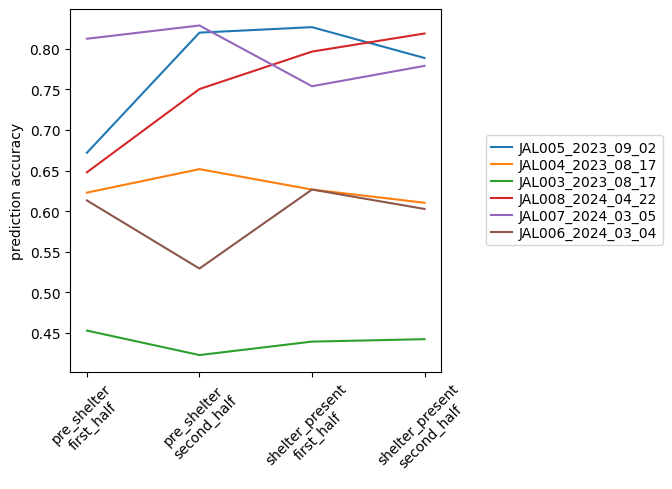

In [46]:
'''Plotting shelter decoding in first vs second half of each condition'''
# pulling out prediction accuracy for all sessions for a certain set of settings
settings = 'all_angles_fr' # has only be computed in the non subsampled one
time_cond = ['first_half','second_half']
conditions_h = conditions 

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings, bar_angles = False, time_cond = time_cond)

angle = 'hsa'
aligned = []
name = []
for c_idx, c in enumerate(conditions):
    for t_idx, t in enumerate(time_cond):
        if len(aligned) == 0:
            aligned = pa[angle][:,c_idx,t_idx]
        else:
            aligned = np.vstack((aligned, pa[angle][:,c_idx,t_idx]))
        name.append(str(c + '\n' + t))

plt.rcParams['figure.figsize'] = [7,5]
plt.plot(aligned)
plt.legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.1, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.xticks(np.arange(np.shape(aligned)[0]), labels=name, rotation = 45)
plt.ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('hsa_pa_time_in_sesh.png'))

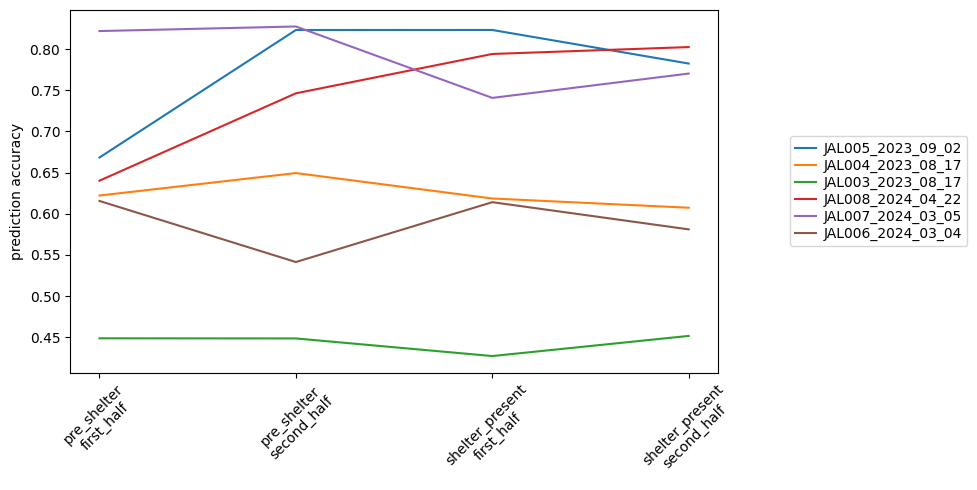

In [38]:
'''Plotting shelter decoding in first vs second half of each condition - use averaged angles'''
# pulling out prediction accuracy for all sessions for a certain set of settings
settings = 'all_angles_fr' # has only be computed in the non subsampled one
time_cond = ['first_half','second_half']
conditions_h = conditions 

# sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings, bar_angles = False, time_cond = time_cond)

angle = 'shelter'
aligned = []
name = []
for c_idx, c in enumerate(conditions):
    for t_idx, t in enumerate(time_cond):
        if len(aligned) == 0:
            aligned = avg_pa[angle][:,c_idx,t_idx]
        else:
            aligned = np.vstack((aligned, avg_pa[angle][:,c_idx,t_idx]))
        name.append(str(c + '\n' + t))

plt.rcParams['figure.figsize'] = [7,5]
plt.plot(aligned)
plt.legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.1, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.xticks(np.arange(np.shape(aligned)[0]), labels=name, rotation = 45)
plt.ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('hsa_avg_pa_time_in_sesh.png'))

- shelter decoding over time/sessions
- difference in shelter decoding vs the whole arena
- extract barrier edges too!